In [1]:
!pip install yfinance pandas numpy arch scikit-learn matplotlib seaborn ta tensorflow

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cffi-2.0.0-cp313-cp313-win_amd64.whl.metadata (2.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


First few rows of the dataset:
Price             Close         High          Low         Open      Volume  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC   
Date                                                                         
2010-01-04  1132.989990  1133.869995  1116.560059  1116.560059  3991400000   
2010-01-05  1136.520020  1136.630005  1129.660034  1132.660034  2491020000   
2010-01-06  1137.140015  1139.189941  1133.949951  1135.709961  4972660000   
2010-01-07  1141.689941  1142.459961  1131.319946  1136.270020  5270680000   
2010-01-08  1144.979980  1145.390015  1136.219971  1140.520020  4389590000   

Price             VIX  
Ticker           ^VIX  
Date                   
2010-01-04  20.040001  
2010-01-05  19.350000  
2010-01-06  19.160000  
2010-01-07  19.059999  
2010-01-08  18.129999  

Missing values in the dataset:
Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
VIX  

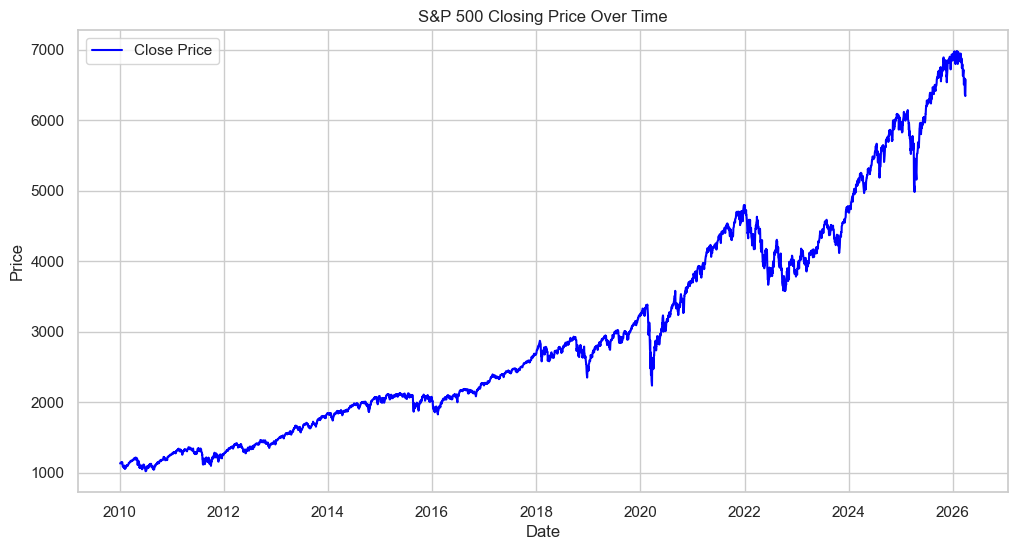

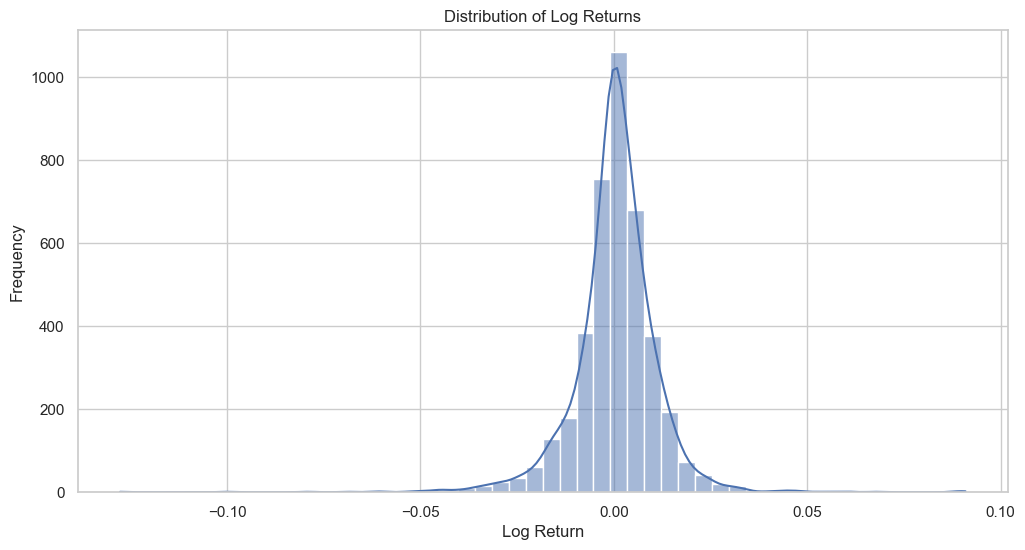

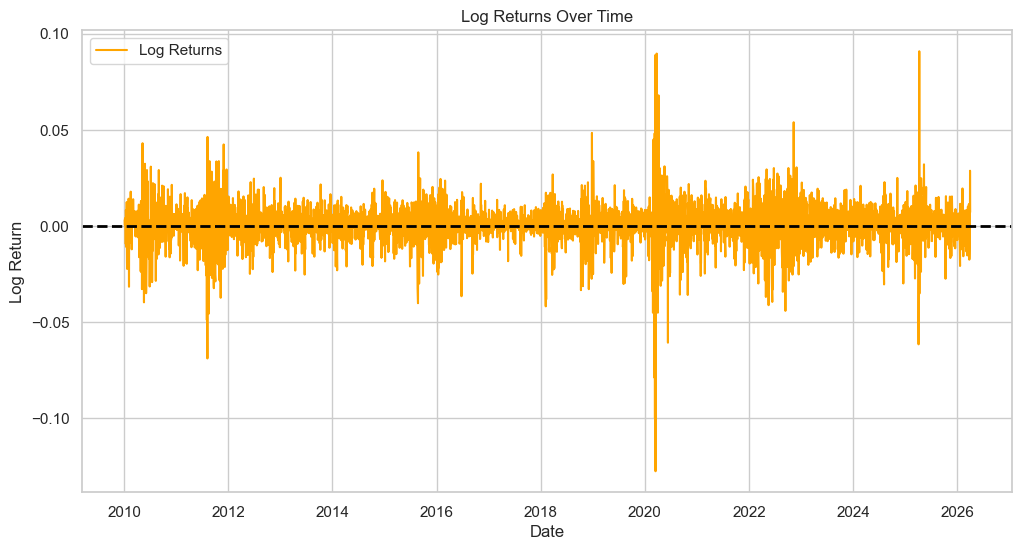

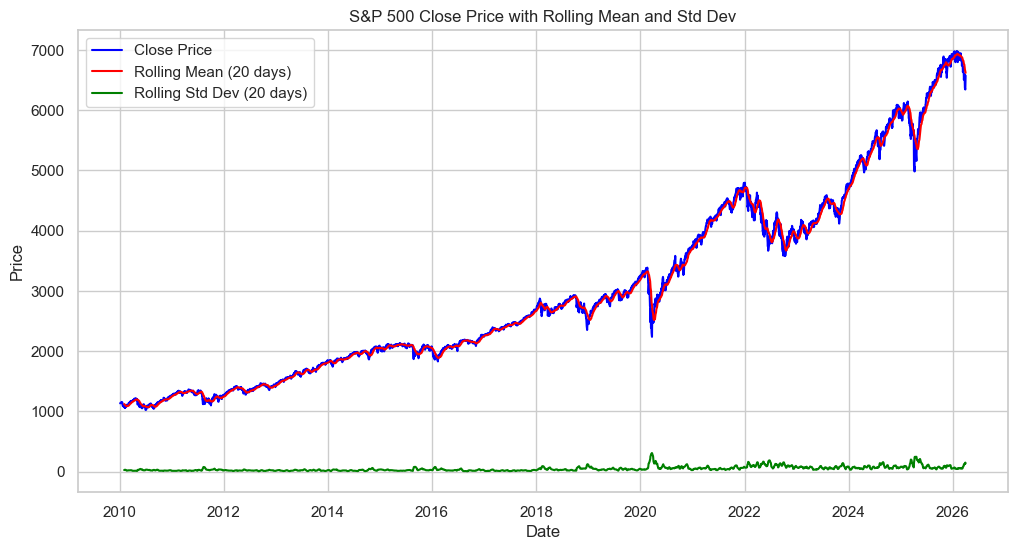

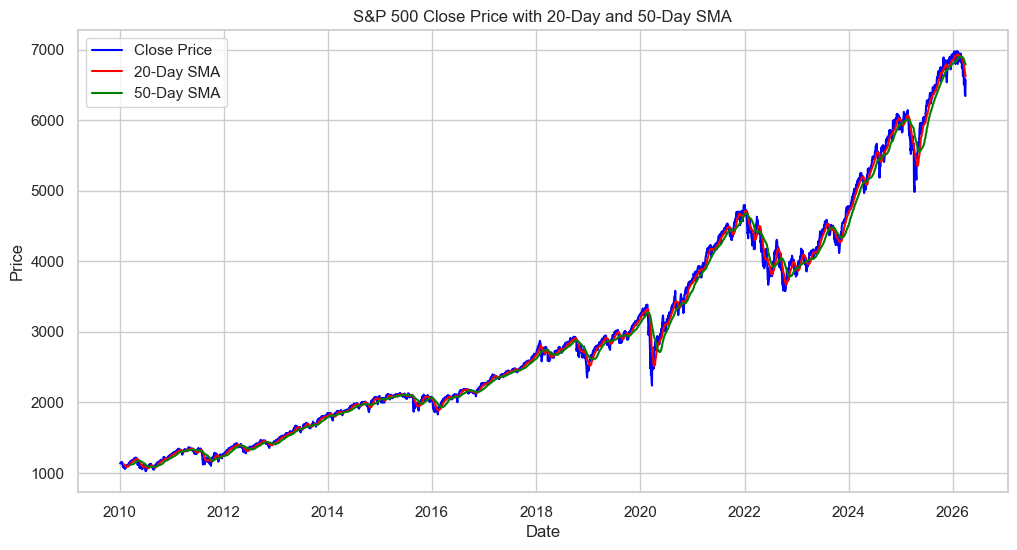

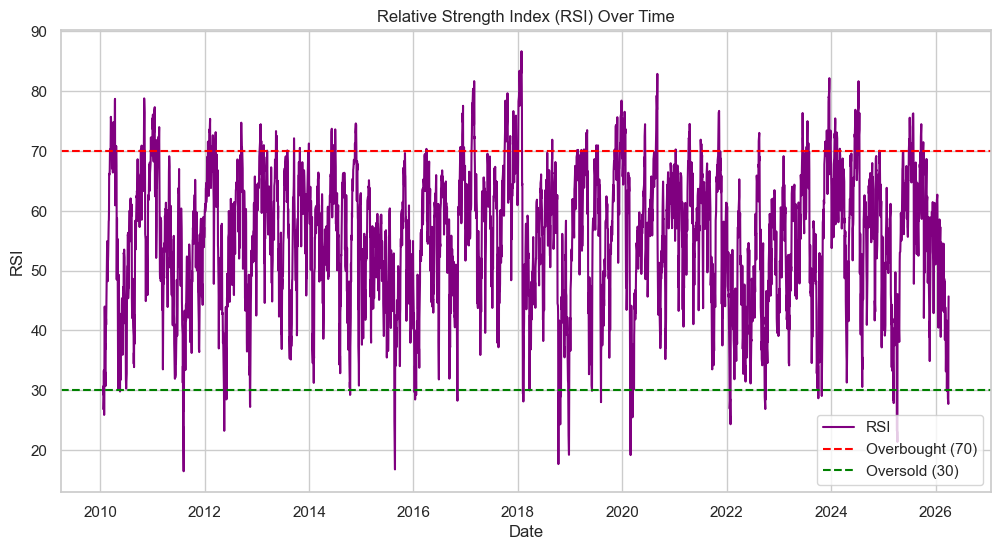

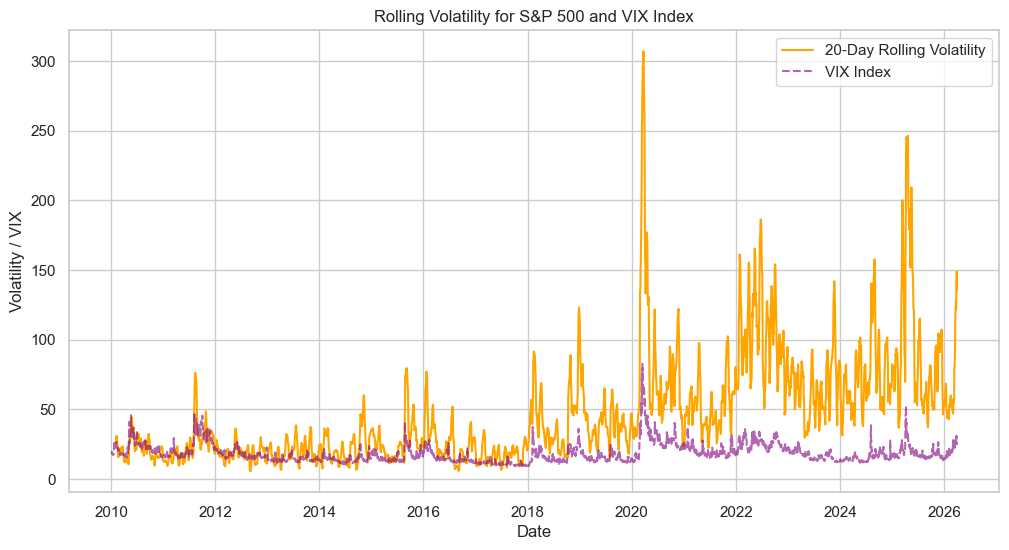

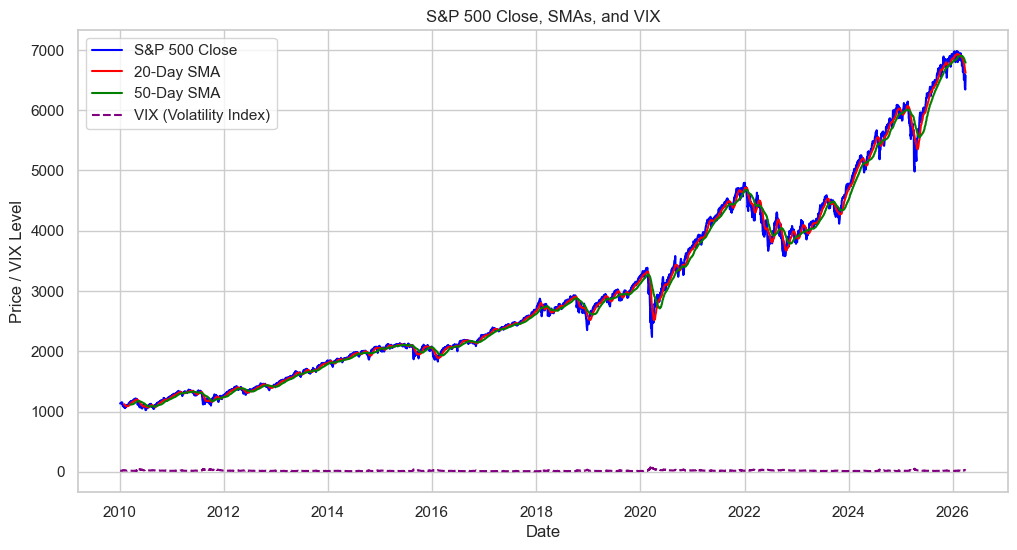

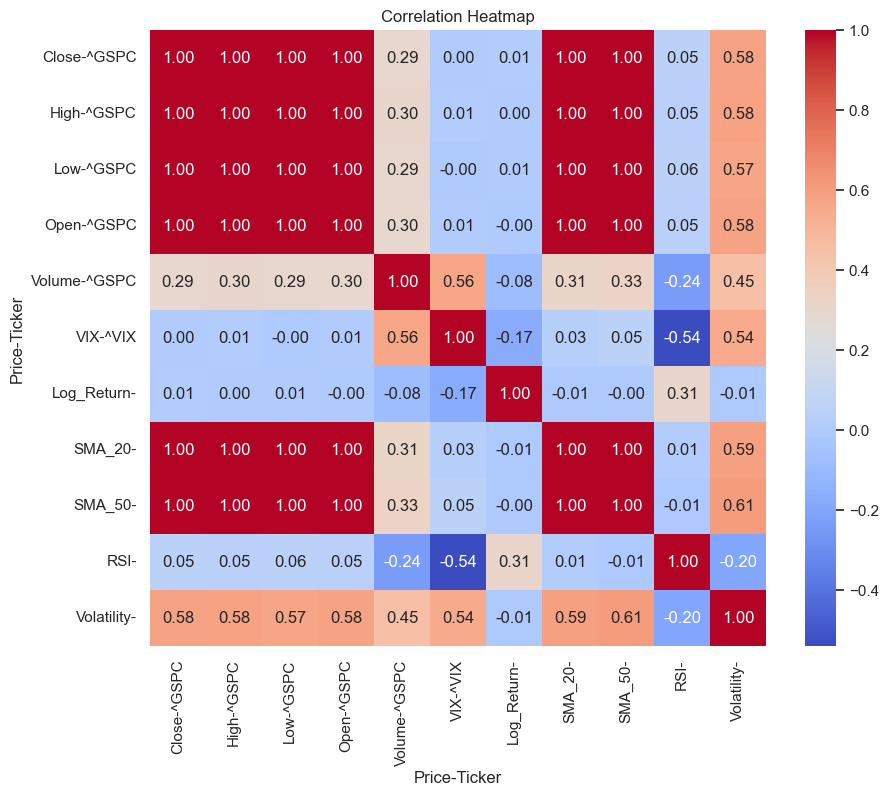

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
from datetime import datetime

sns.set(style='whitegrid')

ticker = '^GSPC'
end_date = datetime.today().strftime('%Y-%m-%d')

data = yf.download(ticker, start='2010-01-01', end=end_date, interval='1d')

vix = yf.download('^VIX', start='2010-01-01', end=end_date, interval='1d')
vix = vix[['Close']].rename(columns={'Close': 'VIX'})

data = data.join(vix, how='inner')

print("First few rows of the dataset:")
print(data.head())

print("\nMissing values in the dataset:")
print(data.isnull().sum())

data.dropna(inplace=True)

# log returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# Creating additional features like 20-day simple moving average, 50-day moving average, RSI and Rolling Std
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['RSI'] = ta.momentum.RSIIndicator(data['Close'].squeeze()).rsi()
data['Volatility'] = data['Close'].rolling(window=20).std()

print("\nCleaned data with additional features:")
print(data.head())

# Summary Statistics
print("\nSummary statistics:")
print(data.describe())

# Closing Price Over Time
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Log Returns Distribution
plt.figure(figsize=(12, 6))
sns.histplot(data['Log_Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# Time Series of Log Returns
plt.figure(figsize=(12, 6))
plt.plot(data['Log_Return'], label='Log Returns', color='orange')
plt.title('Log Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axhline(0, color='black', lw=2, linestyle='--')
plt.legend()
plt.show()

# Rolling Mean and Standard Deviation
rolling_mean = data['Close'].rolling(window=20).mean()
rolling_std = data['Close'].rolling(window=20).std()

plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(rolling_mean, label='Rolling Mean (20 days)', color='red')
plt.plot(rolling_std, label='Rolling Std Dev (20 days)', color='green')
plt.title('S&P 500 Close Price with Rolling Mean and Std Dev')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['SMA_20'], label='20-Day SMA', color='red')
plt.plot(data['SMA_50'], label='50-Day SMA', color='green')
plt.title('S&P 500 Close Price with 20-Day and 50-Day SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# RSI
plt.figure(figsize=(12, 6))
plt.plot(data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Relative Strength Index (RSI) Over Time')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

# Volatility vs VIX
plt.figure(figsize=(12, 6))
plt.plot(data['Volatility'], label='20-Day Rolling Volatility', color='orange')
plt.plot(data['VIX'], label='VIX Index', color='purple', linestyle='--', alpha=0.6)
plt.title('Rolling Volatility for S&P 500 and VIX Index')
plt.xlabel('Date')
plt.ylabel('Volatility / VIX')
plt.legend()
plt.show()

# VIX
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='S&P 500 Close', color='blue')
plt.plot(data['SMA_20'], label='20-Day SMA', color='red')
plt.plot(data['SMA_50'], label='50-Day SMA', color='green')
plt.plot(data['VIX'], label='VIX (Volatility Index)', color='purple', linestyle='--')
plt.title('S&P 500 Close, SMAs, and VIX')
plt.xlabel('Date')
plt.ylabel('Price / VIX Level')
plt.legend()
plt.show()


# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Linear Regression Mean Squared Error: 0.0016087826720852466
Linear Regression R-squared Score: 0.7671564326925807


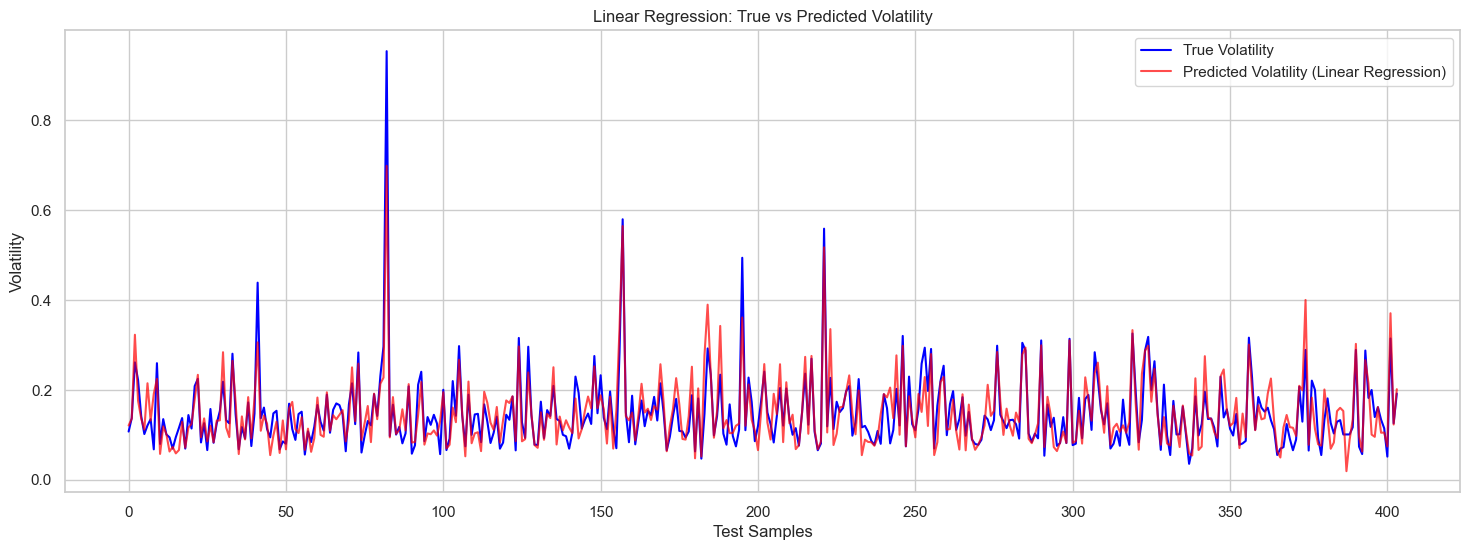

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime

# Set end date to current date
end_date = datetime.today().strftime('%Y-%m-%d')

# Download S&P 500 data
data = yf.download('^GSPC', start='2010-01-01', end=end_date)
data = data[['Close']].copy()

# Feature Engineering
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Volatility'] = data['Log_Return'].rolling(window=21).std() * np.sqrt(252)

# Calculate RSI (Relative Strength Index)
delta = data['Log_Return'].dropna()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# Download VIX data
vix = yf.download('^VIX', start='2010-01-01', end=end_date)
data['VIX'] = vix['Close']

# Drop missing values
data.dropna(inplace=True)

# Features and target variable
X = data[['Close', 'SMA_20', 'SMA_50', 'RSI', 'Log_Return', 'VIX']]  # Features
y = data['Volatility']  # Target: Volatility

# Train-test-validation split: 80% training, 10% validation, 10% testing
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Linear Regression Model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Predictions
y_pred_lin_reg = lin_reg_model.predict(X_test)

# Evaluation metrics for Linear Regression
lin_reg_mse = mean_squared_error(y_test, y_pred_lin_reg)
lin_reg_r2 = r2_score(y_test, y_pred_lin_reg)

# Print evaluation results
print("Linear Regression Mean Squared Error:", lin_reg_mse)
print("Linear Regression R-squared Score:", lin_reg_r2)

# Plot: True vs Predicted Volatility (Linear Regression)
plt.figure(figsize=(18, 6))
plt.plot(y_test.values, label='True Volatility', color='blue')
plt.plot(y_pred_lin_reg, label='Predicted Volatility (Linear Regression)', color='red', alpha=0.7)
plt.title("Linear Regression: True vs Predicted Volatility")
plt.xlabel("Test Samples")
plt.ylabel("Volatility")
plt.legend()
plt.show()